# NautiCost — Cost Prediction Modeling

Predict `final_charge` per yacht service transaction.

**Approach:** LightGBM (primary) + Ridge baseline, time-based split, log-transformed target.
See `../../.claude/plans/staged-swimming-treehouse.md` for the full plan.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.linear_model import Ridge
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error

import lightgbm as lgb

pd.set_option('display.max_columns', 50)
RNG = 42

## 1. Load data

In [2]:
DATA = Path('../004 data/costs_merged.csv')
df = pd.read_csv(DATA)
print(df.shape)
df.head()

(1654, 26)


,yacht_id,office,arrival_port,arrival_date,departure_date,service_type,invoice_comments,supplier,cost_no_vat,final_charge,year,month,stay_days,margin,service_category,flag,gt,nt,loa_m,reg_length_m,beam_m,draft_m,air_draft_m,fuel_lph,loskrav,size_category
0,yacht_10,Bergen Office,Bergen,2024-09-13 00:00:00,2024-09-21 00:00:00,Repair of,Bike Repair + Bike Pump,Unidentified Supplier,335.68,457.98,2024,9,8.0,122.30,Technical Services,NaN,497.0,149.0,53.25,50.88,9.2,3.05,17.0,130.0,Nei,Mellomstor
1,yacht_10,Bergen Office,Bergen,2024-09-15 00:00:00,2024-09-25 00:00:00,Transfer Service,Transfer - Embarking + Disembarking Crew,Unidentified Supplier,576.87,917.27,2024,9,10.0,340.40,Hospitality,NaN,497.0,149.0,53.25,50.88,9.2,3.05,17.0,130.0,Nei,Mellomstor
2,yacht_10,Bergen Office,Bergen,2024-09-18 00:00:00,2024-09-26 00:00:00,Purchasing Assistance,Purchase Assistance - SD Charts,Unidentified Supplier,201.73,247.15,2024,9,8.0,45.42,Agency Services,NaN,497.0,149.0,53.25,50.88,9.2,3.05,17.0,130.0,Nei,Mellomstor
3,yacht_10,Bergen Office,Bergen,2024-09-18 00:00:00,2024-09-26 00:00:00,Custom Formalities,Entry Clearance into Norway,NaN,0.00,251.04,2024,9,8.0,251.04,Agency Services,NaN,497.0,149.0,53.25,50.88,9.2,3.05,17.0,130.0,Nei,Mellomstor
4,yacht_10,Bergen Office,Bergen,2024-09-18 00:00:00,2024-09-28 00:00:00,Purchasing Assistance,Purchase Assistance - Beers,Unidentified Supplier,160.86,221.49,2024,9,10.0,60.63,Agency Services,NaN,497.0,149.0,53.25,50.88,9.2,3.05,17.0,130.0,Nei,Mellomstor


In [3]:
# Drop rows with missing target
df = df.dropna(subset=['final_charge'])
df = df[df['final_charge'] > 0].copy()
print('After filtering:', df.shape)
df['final_charge'].describe()

After filtering: (1633, 26)


count      1633.000000
mean      25044.820269
std       57589.474465
min          15.110000
25%        2039.060000
50%        7512.970000
75%       21950.000000
max      657504.100000
Name: final_charge, dtype: float64

## 2. Features and target

In [4]:
CAT_FEATURES = ['office', 'arrival_port', 'service_type', 'service_category', 'size_category', 'loskrav']
NUM_FEATURES = ['gt', 'loa_m', 'beam_m', 'draft_m', 'fuel_lph', 'stay_days', 'month']
FEATURES = CAT_FEATURES + NUM_FEATURES
TARGET = 'final_charge'

for c in CAT_FEATURES:
    df[c] = df[c].astype('category')

df[FEATURES].dtypes

office              category
arrival_port        category
service_type        category
service_category    category
size_category       category
loskrav             category
gt                   float64
loa_m                float64
beam_m               float64
draft_m              float64
fuel_lph             float64
stay_days            float64
month                  int64
dtype: object

### 2b. Feature engineering
Temporal, interaction, and text-based features derived from existing columns.

In [5]:
def build_features(df, yacht_stats=None):
    """Add engineered features. If yacht_stats is None, fit on rows where year<=2024."""
    df = df.copy()

    # Temporal
    df['quarter'] = ((df['month'] - 1) // 3 + 1).astype('int8')
    df['is_summer'] = df['month'].isin([6, 7, 8]).astype('int8')
    df['is_shoulder'] = df['month'].isin([5, 9]).astype('int8')

    # Numeric interactions
    df['gt_x_stay']   = df['gt'].fillna(0) * df['stay_days'].fillna(0)
    df['loa_x_stay']  = df['loa_m'].fillna(0) * df['stay_days'].fillna(0)
    df['fuel_x_stay'] = df['fuel_lph'].fillna(0) * df['stay_days'].fillna(0)

    # Yacht-level aggregates (fit on train period only to avoid leakage)
    if yacht_stats is None:
        hist = df[df['year'] <= 2024]
        yacht_stats = hist.groupby('yacht_id')['final_charge'].agg(
            yacht_mean_charge='mean', yacht_visit_count='count'
        ).reset_index()
    df = df.merge(yacht_stats, on='yacht_id', how='left')
    df['yacht_mean_charge'] = df['yacht_mean_charge'].fillna(df['yacht_mean_charge'].median())
    df['yacht_visit_count'] = df['yacht_visit_count'].fillna(0)

    # Text signals from invoice_comments
    cmt = df['invoice_comments'].fillna('').astype(str).str.lower()
    df['cmt_len']        = cmt.str.len().astype('int16')
    df['cmt_has_urgent'] = cmt.str.contains('urgent|asap|rush', regex=True).astype('int8')
    df['cmt_has_repair'] = cmt.str.contains('repair|fix|broken', regex=True).astype('int8')
    df['cmt_has_fuel']   = cmt.str.contains('fuel|diesel|bunker', regex=True).astype('int8')

    return df, yacht_stats

NEW_NUM = ['quarter','is_summer','is_shoulder','gt_x_stay','loa_x_stay','fuel_x_stay',
           'yacht_mean_charge','yacht_visit_count','cmt_len','cmt_has_urgent',
           'cmt_has_repair','cmt_has_fuel']
NUM_FEATURES = NUM_FEATURES + NEW_NUM
FEATURES = CAT_FEATURES + NUM_FEATURES

df, yacht_stats = build_features(df)
print(f'Total features: {len(FEATURES)} ({len(CAT_FEATURES)} cat + {len(NUM_FEATURES)} num)')

Total features: 25 (6 cat + 19 num)


## 3. Time-based split
train ≤ 2024, val = 2025, test = 2026

In [6]:
train = df[df['year'] <= 2024]
val   = df[df['year'] == 2025]
test  = df[df['year'] == 2026]
print('train', train.shape, 'val', val.shape, 'test', test.shape)

def xy(sub):
    X = sub[FEATURES].copy()
    y = np.log1p(sub[TARGET].values)
    return X, y

X_tr, y_tr = xy(train)
X_va, y_va = xy(val)
X_te, y_te = xy(test)

train (977, 38) val (649, 38) test (7, 38)


## 4. Baseline: median predictor & Ridge

In [7]:
def eval_pred(y_true_log, y_pred_log, label):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1))) * 100
    print(f'{label:20s} MAE={mae:10.0f}  RMSE={rmse:10.0f}  MAPE={mape:6.1f}%')
    return mae, rmse, mape

med = np.median(y_tr)
eval_pred(y_va, np.full_like(y_va, med), 'Median baseline')

Median baseline      MAE=     23103  RMSE=     65949  MAPE= 464.1%


(23102.974314329735,
 np.float64(65949.30869352716),
 np.float64(464.0532793079357))

In [8]:
pre = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), CAT_FEATURES),
    ('num', StandardScaler(), NUM_FEATURES),
])
ridge = Pipeline([('pre', pre), ('reg', Ridge(alpha=1.0, random_state=RNG))])
ridge.fit(X_tr.fillna(-1), y_tr)
eval_pred(y_va, ridge.predict(X_va.fillna(-1)), 'Ridge (val)')

Ridge (val)          MAE=     22948  RMSE=     63508  MAPE= 680.9%


(22948.30937131301,
 np.float64(63507.86311774566),
 np.float64(680.9139941680612))

## 5. LightGBM

In [9]:
lgb_params = dict(
    objective='regression',
    metric='mae',
    learning_rate=0.05,
    num_leaves=63,
    min_data_in_leaf=10,
    feature_fraction=0.9,
    bagging_fraction=0.9,
    bagging_freq=5,
    random_state=RNG,
    verbose=-1,
)

dtrain = lgb.Dataset(X_tr, y_tr, categorical_feature=CAT_FEATURES)
dval   = lgb.Dataset(X_va, y_va, categorical_feature=CAT_FEATURES, reference=dtrain)

model = lgb.train(
    lgb_params,
    dtrain,
    num_boost_round=2000,
    valid_sets=[dtrain, dval],
    valid_names=['train', 'val'],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)],
)

Training until validation scores don't improve for 50 rounds


[100]	train's l1: 0.35144	val's l1: 0.729015


[200]	train's l1: 0.23057	val's l1: 0.677908


[300]	train's l1: 0.181756	val's l1: 0.659335


[400]	train's l1: 0.155488	val's l1: 0.654578


Early stopping, best iteration is:
[383]	train's l1: 0.158659	val's l1: 0.653278


In [10]:
pred_va = model.predict(X_va, num_iteration=model.best_iteration)
eval_pred(y_va, pred_va, 'LightGBM (val)')

if len(X_te):
    pred_te = model.predict(X_te, num_iteration=model.best_iteration)
    eval_pred(y_te, pred_te, 'LightGBM (test)')

LightGBM (val)       MAE=     13860  RMSE=     47390  MAPE= 164.9%
LightGBM (test)      MAE=     15308  RMSE=     22257  MAPE=  24.5%


## 6. Feature importance

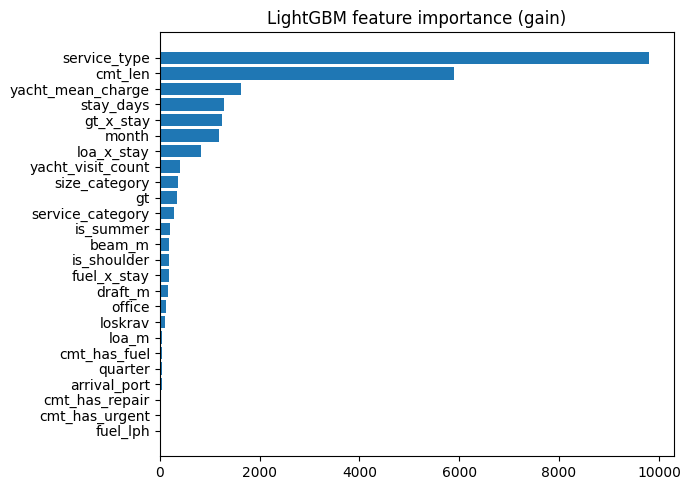

In [11]:
imp = pd.DataFrame({
    'feature': model.feature_name(),
    'gain': model.feature_importance(importance_type='gain'),
}).sort_values('gain', ascending=True)

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(imp['feature'], imp['gain'])
ax.set_title('LightGBM feature importance (gain)')
plt.tight_layout()
plt.show()

## 7. Quantile predictions (P10 / P50 / P90)

In [12]:
quantile_models = {}
for q in [0.1, 0.5, 0.9]:
    p = {**lgb_params, 'objective': 'quantile', 'alpha': q, 'metric': 'quantile'}
    m = lgb.train(p, dtrain, num_boost_round=model.best_iteration or 500,
                  valid_sets=[dval], callbacks=[lgb.log_evaluation(0)])
    quantile_models[q] = m

preds = {q: np.expm1(m.predict(X_va)) for q, m in quantile_models.items()}
out = pd.DataFrame({
    'actual': np.expm1(y_va),
    'p10': preds[0.1], 'p50': preds[0.5], 'p90': preds[0.9],
}).head(15)
out

,actual,p10,p50,p90
0,1288.10,1964.560956,11189.622254,8377.447800
1,2772.00,2397.965164,5185.096457,7353.193469
2,11869.00,5629.734660,9343.103365,7201.871141
3,2200.00,1464.980784,2405.999783,4271.430181
4,15342.25,9719.405324,22498.418233,35604.830034
5,5549.50,916.429841,3270.647148,5942.569217
6,1994.86,1115.853035,1558.337309,3158.553476
7,4799.41,3167.535608,5461.628860,10799.149385
8,1500.13,1115.853035,1558.337309,3158.553476
9,365.20,409.538722,1412.644834,4017.595323


## 8. CatBoost (native categorical handling)

In [13]:
from catboost import CatBoostRegressor

X_tr_cb = X_tr.copy()
X_va_cb = X_va.copy()
for c in CAT_FEATURES:
    X_tr_cb[c] = X_tr_cb[c].astype(str).fillna('NA')
    X_va_cb[c] = X_va_cb[c].astype(str).fillna('NA')

cb = CatBoostRegressor(
    iterations=2000, learning_rate=0.05, depth=6,
    loss_function='MAE', cat_features=CAT_FEATURES,
    early_stopping_rounds=50, random_seed=RNG, verbose=0,
)
cb.fit(X_tr_cb, y_tr, eval_set=(X_va_cb, y_va))
eval_pred(y_va, cb.predict(X_va_cb), 'CatBoost (val)')

CatBoost (val)       MAE=     17387  RMSE=     60457  MAPE= 176.7%


(17386.758107305697,
 np.float64(60457.3572775571),
 np.float64(176.71586978720774))

## 9. Hyperparameter tuning with Optuna (LightGBM)

In [14]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    p = dict(
        objective='regression', metric='mae', verbose=-1, random_state=RNG,
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        num_leaves=trial.suggest_int('num_leaves', 15, 127),
        min_data_in_leaf=trial.suggest_int('min_data_in_leaf', 5, 50),
        feature_fraction=trial.suggest_float('feature_fraction', 0.6, 1.0),
        bagging_fraction=trial.suggest_float('bagging_fraction', 0.6, 1.0),
        bagging_freq=5,
        lambda_l2=trial.suggest_float('lambda_l2', 1e-3, 10, log=True),
    )
    dtr = lgb.Dataset(X_tr, y_tr, categorical_feature=CAT_FEATURES)
    dva = lgb.Dataset(X_va, y_va, categorical_feature=CAT_FEATURES, reference=dtr)
    m = lgb.train(p, dtr, num_boost_round=1500, valid_sets=[dva],
                  callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)])
    pred = m.predict(X_va, num_iteration=m.best_iteration)
    return mean_absolute_error(np.expm1(y_va), np.expm1(pred))

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=30, show_progress_bar=False)
print('Best MAE:', study.best_value)
print('Best params:', study.best_params)

Best MAE: 13584.000881886646
Best params: {'learning_rate': 0.05908007111745629, 'num_leaves': 40, 'min_data_in_leaf': 13, 'feature_fraction': 0.8981101590427778, 'bagging_fraction': 0.943805021694051, 'lambda_l2': 2.573832119458069}


In [15]:
# Train final tuned LightGBM model
tuned_params = dict(objective='regression', metric='mae', verbose=-1,
                    random_state=RNG, bagging_freq=5, **study.best_params)
dtr = lgb.Dataset(X_tr, y_tr, categorical_feature=CAT_FEATURES)
dva = lgb.Dataset(X_va, y_va, categorical_feature=CAT_FEATURES, reference=dtr)
best_model = lgb.train(
    tuned_params, dtr, num_boost_round=2000, valid_sets=[dva],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)],
)
eval_pred(y_va, best_model.predict(X_va, num_iteration=best_model.best_iteration), 'Tuned LightGBM')

Tuned LightGBM       MAE=     13584  RMSE=     46782  MAPE= 162.1%


(13584.000881886646,
 np.float64(46781.92904677317),
 np.float64(162.11829184636997))

## 10. SHAP explainability

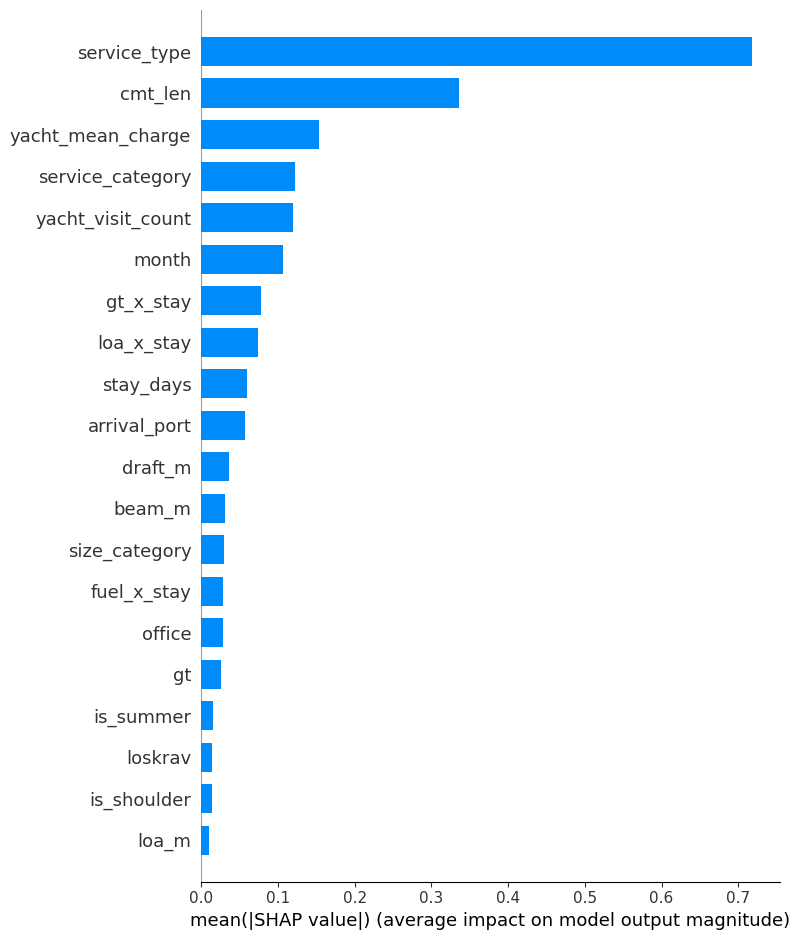

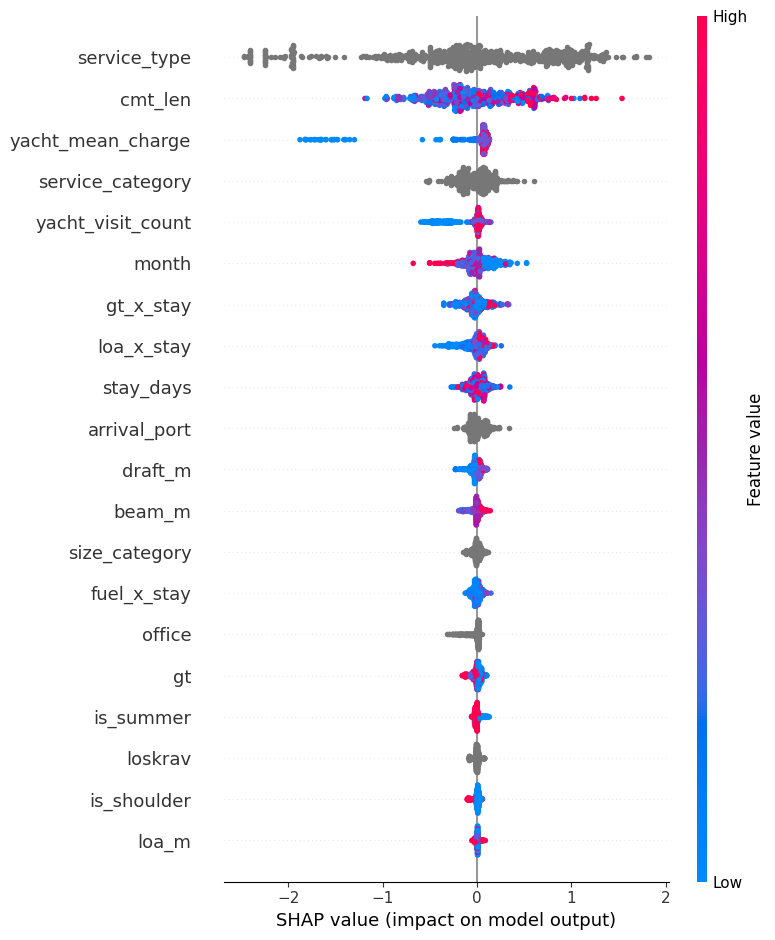

In [16]:
import shap

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_va)

# Summary plot (global feature impact)
shap.summary_plot(shap_values, X_va, plot_type='bar', show=False)
plt.tight_layout(); plt.show()

shap.summary_plot(shap_values, X_va, show=False)
plt.tight_layout(); plt.show()

In [17]:
# Per-row explanation: top 5 rows with largest prediction
pred_va = best_model.predict(X_va, num_iteration=best_model.best_iteration)
top_idx = np.argsort(-pred_va)[:5]
for i in top_idx:
    print(f"row={i}  actual={np.expm1(y_va[i]):,.0f}  predicted={np.expm1(pred_va[i]):,.0f}")
    contribs = pd.Series(shap_values[i], index=FEATURES).sort_values(key=np.abs, ascending=False)
    print(contribs.head(5).to_string(), '\n')

row=412  actual=577,570  predicted=354,182
service_type         1.816674
cmt_len              1.026016
loa_x_stay           0.180409
month                0.168570
yacht_visit_count    0.147147 

row=340  actual=657,504  predicted=253,623
service_type         1.540792
cmt_len              1.090265
gt_x_stay            0.326510
service_category     0.180913
yacht_mean_charge    0.104516 

row=308  actual=550,000  predicted=220,228
service_type        0.996951
service_category    0.354809
stay_days           0.346935
gt_x_stay           0.335710
cmt_len             0.317881 

row=290  actual=176,556  predicted=157,378
service_type    1.334298
cmt_len         0.747208
arrival_port    0.229509
gt_x_stay       0.214608
stay_days       0.172397 

row=309  actual=388,468  predicted=155,129
service_type        1.313860
cmt_len             0.755979
gt_x_stay           0.270341
stay_days           0.234199
service_category    0.155877 



## 11. Residual diagnostics
Where does the tuned model err? Look at residuals vs predicted, by segment, and inspect the worst misses.

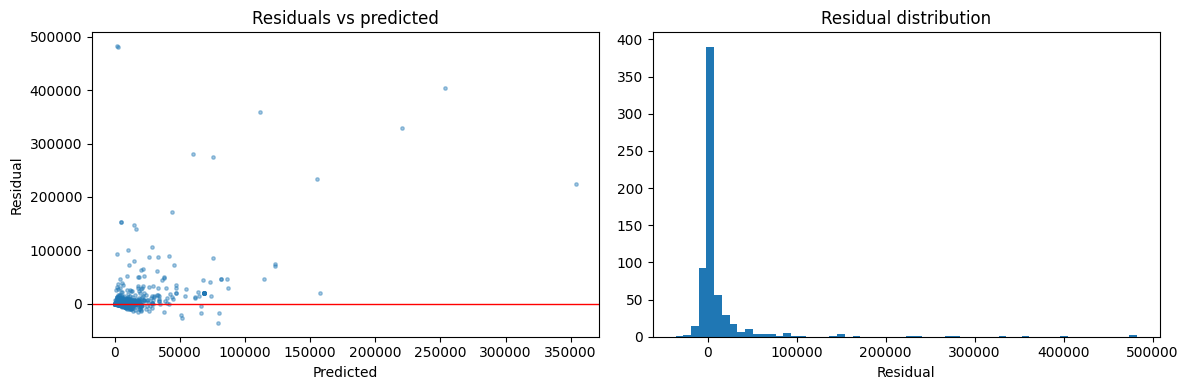

Mean residual:   11,370
Median residual: 864
Std residual:    45,379


In [18]:
pred_va_lin = np.expm1(best_model.predict(X_va, num_iteration=best_model.best_iteration))
actual_va = np.expm1(y_va)
resid = actual_va - pred_va_lin

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(pred_va_lin, resid, s=6, alpha=0.4)
axes[0].axhline(0, color='red', lw=1)
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Residual'); axes[0].set_title('Residuals vs predicted')
axes[1].hist(resid, bins=60)
axes[1].set_xlabel('Residual'); axes[1].set_title('Residual distribution')
plt.tight_layout(); plt.show()

print(f'Mean residual:   {resid.mean():,.0f}')
print(f'Median residual: {np.median(resid):,.0f}')
print(f'Std residual:    {resid.std():,.0f}')

In [19]:
diag = val[FEATURES + [TARGET]].copy()
diag['pred'] = pred_va_lin
diag['abs_err'] = np.abs(resid)
diag['ape'] = diag['abs_err'] / np.maximum(diag[TARGET], 1)

by_service = diag.groupby('service_category', observed=True).agg(
    n=('pred', 'size'), mae=('abs_err', 'mean'), mape=('ape', 'mean')
).sort_values('mae', ascending=False)
print('By service_category:'); print(by_service, '\n')

by_size = diag.groupby('size_category', observed=True).agg(
    n=('pred', 'size'), mae=('abs_err', 'mean'), mape=('ape', 'mean')
).sort_values('mae', ascending=False)
print('By size_category:'); print(by_size)

By service_category:
                      n           mae      mape
service_category                               
Bunkering            20  39893.409911  0.464026
Provisioning         71  39093.637293  7.594065
Technical Services   48  16229.423957  0.445439
Port Marina         144  15740.171472  1.097291
Agency Fee           25  13089.285504  1.139246
Hospitality         121   9381.093746  0.794595
Agency Services     220   3338.902743  0.907593 

By size_category:
                 n           mae      mape
size_category                             
Stor           226  22954.121895  0.902351
Mellomstor     214   9386.683505  0.715216
Liten          209   7749.448585  3.326125


In [20]:
worst = diag.nlargest(10, 'abs_err')[['service_category','size_category','gt','stay_days', TARGET,'pred','abs_err']]
worst

,service_category,size_category,gt,stay_days,final_charge,pred,abs_err
1234,Provisioning,Stor,2407.0,2.0,484028.60,1648.489668,482380.110332
1250,Provisioning,Stor,2407.0,2.0,484028.60,2374.814574,481653.785426
1318,Provisioning,Stor,2407.0,10.0,657504.10,253622.601812,403881.498188
1421,Port Marina,Stor,2149.0,27.0,470574.50,111652.548439,358921.951561
1286,Hospitality,Stor,2407.0,6.0,550000.00,220228.023120,329771.976880
1261,Port Marina,Stor,2407.0,10.0,340666.00,60214.150191,280451.849809
1366,Provisioning,Stor,2149.0,27.0,349570.63,75467.273352,274103.356648
1287,Provisioning,Stor,2407.0,6.0,388468.30,155129.061453,233339.238547
1396,Port Marina,Stor,2149.0,27.0,577570.00,354181.599862,223388.400138
1375,Agency Fee,Stor,2149.0,27.0,215140.00,43934.027405,171205.972595


## 12. Final test-set evaluation & model artifact

In [21]:
if len(X_te):
    pred_te = best_model.predict(X_te, num_iteration=best_model.best_iteration)
    eval_pred(y_te, pred_te, 'Tuned LightGBM (test)')
else:
    print('No 2026 test rows available.')

Tuned LightGBM (test) MAE=     15372  RMSE=     22167  MAPE=  23.7%


In [22]:
import joblib
ART = Path('artifacts'); ART.mkdir(exist_ok=True)
best_model.save_model(str(ART / 'lgbm_tuned.txt'))
joblib.dump({'features': FEATURES, 'cat_features': CAT_FEATURES, 'num_features': NUM_FEATURES,
             'best_params': study.best_params, 'best_iteration': best_model.best_iteration},
            ART / 'model_meta.joblib')
print('Saved to', ART.resolve())

Saved to C:\Users\jorge\OneDrive - Høgskolen i Molde\LOG650 - Forskningsprosjekt\LOG650_NautiCost\G11-jorgen-individuell\013 fase 3 - review\artifacts


## 13. Final production model — refit on ALL data
Retrain LightGBM with the tuned hyperparameters on train + val + test combined, using `best_iteration` from the validation-tuned model (no early stopping possible without a holdout).

In [23]:
df_final = df[df['year'].between(2020, 2025)].copy()
X_all = df_final[FEATURES].copy()
y_all = np.log1p(df_final[TARGET].values)
print('Full dataset:', X_all.shape, '| years:', sorted(df_final['year'].unique()))

dall = lgb.Dataset(X_all, y_all, categorical_feature=CAT_FEATURES)
final_model = lgb.train(
    tuned_params,
    dall,
    num_boost_round=best_model.best_iteration,
    callbacks=[lgb.log_evaluation(0)],
)
print('Final model trained on', len(X_all), 'rows for', best_model.best_iteration, 'iterations.')

Full dataset: (1626, 25) | years: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


Final model trained on 1626 rows for 670 iterations.


In [24]:
final_model.save_model(str(ART / 'lgbm_final_full.txt'))
yacht_stats.to_parquet(ART / 'yacht_stats.parquet', index=False)
joblib.dump({'features': FEATURES, 'cat_features': CAT_FEATURES, 'num_features': NUM_FEATURES,
             'best_params': study.best_params, 'num_iterations': best_model.best_iteration,
             'trained_on_rows': len(X_all), 'years': sorted(df_final['year'].unique().tolist())},
            ART / 'model_meta_final.joblib')
print('Saved final model to', (ART / 'lgbm_final_full.txt').resolve())

Saved final model to C:\Users\jorge\OneDrive - Høgskolen i Molde\LOG650 - Forskningsprosjekt\LOG650_NautiCost\G11-jorgen-individuell\013 fase 3 - review\artifacts\lgbm_final_full.txt


## 14. Quantile coverage check
Verify the P10/P50/P90 quantile models are well-calibrated on the validation set.

In [25]:
p10 = np.expm1(quantile_models[0.1].predict(X_va))
p50 = np.expm1(quantile_models[0.5].predict(X_va))
p90 = np.expm1(quantile_models[0.9].predict(X_va))
actual = np.expm1(y_va)

cov_80 = np.mean((actual >= p10) & (actual <= p90)) * 100
cov_50 = np.mean((actual >= p50) & (actual <= p90)) * 100  # upper half
print(f'[P10, P90] coverage: {cov_80:5.1f}%  (nominal 80%)')
print(f'[P50, P90] coverage: {cov_50:5.1f}%  (nominal 40%)')
if abs(cov_80 - 80) > 10:
    print('WARNING: P10/P90 band miscalibrated by >10pp')

[P10, P90] coverage:  41.6%  (nominal 80%)
[P50, P90] coverage:  23.4%  (nominal 40%)


## 15. Model comparison summary

In [26]:
def metrics_only(y_true_log, y_pred_log):
    yt = np.expm1(y_true_log); yp = np.expm1(y_pred_log)
    return (mean_absolute_error(yt, yp),
            np.sqrt(mean_squared_error(yt, yp)),
            np.mean(np.abs((yt - yp) / np.maximum(yt, 1))) * 100)

rows = []
rows.append(('Median baseline',  *metrics_only(y_va, np.full_like(y_va, np.median(y_tr)))))
rows.append(('Ridge',             *metrics_only(y_va, ridge.predict(X_va.fillna(-1)))))
rows.append(('LightGBM (base)',   *metrics_only(y_va, model.predict(X_va, num_iteration=model.best_iteration))))
rows.append(('CatBoost',          *metrics_only(y_va, cb.predict(X_va_cb))))
rows.append(('LightGBM (tuned)',  *metrics_only(y_va, best_model.predict(X_va, num_iteration=best_model.best_iteration))))

summary = pd.DataFrame(rows, columns=['model', 'MAE', 'RMSE', 'MAPE']).sort_values('MAE').reset_index(drop=True)
summary.to_csv(ART / 'metrics.csv', index=False)
summary

,model,MAE,RMSE,MAPE
0,LightGBM (tuned),13584.000882,46781.929047,162.118292
1,LightGBM (base),13859.594062,47389.533291,164.890569
2,CatBoost,17386.758107,60457.357278,176.715870
3,Ridge,22948.309371,63507.863118,680.913994
4,Median baseline,23102.974314,65949.308694,464.053279


## 16. Inference helper + smoke test
Load the saved artifact from disk and predict on a few rows to confirm the artifact is self-contained.

In [27]:
loaded_model = lgb.Booster(model_file=str(ART / 'lgbm_final_full.txt'))
loaded_meta  = joblib.load(ART / 'model_meta_final.joblib')
loaded_stats = pd.read_parquet(ART / 'yacht_stats.parquet')

def predict_charge(raw_df):
    feats, _ = build_features(raw_df, yacht_stats=loaded_stats)
    for c in loaded_meta['cat_features']:
        feats[c] = feats[c].astype('category')
    X = feats[loaded_meta['features']]
    return np.expm1(loaded_model.predict(X))

# Smoke test on first 3 rows of the raw merged file
raw = pd.read_csv(DATA).dropna(subset=['final_charge']).head(3)
preds = predict_charge(raw)
for i, (a, p) in enumerate(zip(raw['final_charge'].values, preds)):
    print(f'row {i}: actual={a:>10,.0f}  predicted={p:>10,.0f}')

row 0: actual=       458  predicted=       513
row 1: actual=       917  predicted=       948
row 2: actual=       247  predicted=       247
